# Data preparation - Feature Engineering
Created by Guillermo Arredondo Renero

Creation date: May 4, 2026  
Last updated: May 5, 2026

**Main objective**: Realize feature engineering over interim data (cleaned data) to empower models in next stage. **Only for binary classification of default clients**

In [ ]:
# ---------------------------- Libraries
## Directories
import os
## Data manipulation
import pandas as pd
import numpy as np

## Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable

# Extras
import warnings
warnings.filterwarnings('ignore')

# Transformation
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [ ]:
# ---------------------------- Directories
# Get main directory
CURRENT_DIR = os.getcwd()
MAIN_DIR = os.path.dirname(CURRENT_DIR)
INTERIM_DIR = os.path.join(MAIN_DIR, 'data', 'interim')
PROCESSED_DIR = os.path.join(MAIN_DIR, 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

## Data loading

In [ ]:
df = pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv'))

## Transformations

### Categorical variables

Dado que no son muchas categorías para las variables categóricas no tenemos problema en usar One-Hot Encoding.  
Nótese que crearemos las variables dummy, sin embargo, más adelante de acuerdo al tipo de modelo que se vaya a utilizar se seleccionarán las variables ya que pudieramos usar la variable en forma ordinal para árboles de decisión. 

*Nota:* aquí podría usarse una categorización por medio de WOE para generar agrupaciones de categorías similares o para categorizar (a través de bins) las variables continuas.

In [ ]:
# Get Female dummy variable
df['Female'] = df['SEX'] - 1

# Replace marriage and education with mapping
education_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'}
marriage_map = {1: 'Married', 2: 'Single', 3: 'Others'}
# df['EDUCATION'] = df['EDUCATION'].map(education_map)
# df['MARRIAGE'] = df['MARRIAGE'].map(marriage_map)

# Create One Hot Encodings for MARRIAGE and EDUCATION
df = pd.concat(
    [
        df,
        pd.get_dummies(df.MARRIAGE.map(marriage_map), prefix='MARRIAGE').astype(int),
        pd.get_dummies(df.EDUCATION.map(education_map), prefix='EDUCATION').astype(int)
    ],
    axis=1
)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT6,default_payment_next_month,Female,MARRIAGE_Married,MARRIAGE_Others,MARRIAGE_Single,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Others,EDUCATION_University
0,20000,2,2,1,24,3,3,-1,-1,-1,...,0,1,1,1,0,0,0,0,0,1
1,120000,2,2,2,26,-1,3,1,1,1,...,2000,1,1,0,0,1,0,0,0,1
2,90000,2,2,2,34,1,1,1,1,1,...,5000,0,1,0,0,1,0,0,0,1
3,50000,2,2,1,37,1,1,1,1,1,...,1000,0,1,1,0,0,0,0,0,1
4,50000,1,2,1,57,-1,1,-1,1,1,...,679,0,0,1,0,0,0,0,0,1


### New variables

In [ ]:
# Calculate credit utilization (most recent bill amount / credit limit)
df['credit_utilization'] = df['BILL_AMT1'] / df['LIMIT_BAL']  # BILL_AMT1 is most recent bill amount

# Calculate average monthly bill and payment
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

df['avg_monthly_bill'] = df[bill_cols].mean(axis=1)
df['avg_monthly_payment'] = df[pay_amt_cols].mean(axis=1)

# Create a feature: maximum payment delay across 6 months
df['max_payment_delay'] = df[pay_cols].max(axis=1)
df['has_any_delay'] = (df['max_payment_delay'] > 0).astype(int)

# # ========== ADVANCED PAYMENT BEHAVIOR FEATURES ==========

# # 1. Recent Payment Status Indicators
# # Most recent payment status (PAY_1) is strongest predictor - create specific flags
# df['recent_delay_1month'] = (df['PAY_1'] == 1).astype(int)  # Exactly 1 month delay
# df['recent_delay_2months'] = (df['PAY_1'] == 2).astype(int)  # Exactly 2 months delay
# df['recent_delay_2plus'] = (df['PAY_1'] >= 2).astype(int)  # 2+ months delay (serious)
# df['recent_paid_on_time'] = (df['PAY_1'] <= 0).astype(int)  # Paid on time or in advance

# # 2. Historical Payment Delay Pattern
# # Count months with any delay
# df['months_with_delay'] = (df[pay_cols] > 0).sum(axis=1)
# df['pct_months_with_delay'] = df['months_with_delay'] / len(pay_cols)

# # 3. Severity of Payment Delays
# df['severe_delay_count'] = (df[pay_cols] >= 2).sum(axis=1)  # Count months with 2+ month delays
# df['has_severe_delay'] = (df['severe_delay_count'] > 0).astype(int)  # Any serious delay indicator

# # 4. Payment Consistency (Volatility)
# # Low volatility in payments is good, high volatility is concerning
# df['payment_volatility'] = df[pay_amt_cols].std(axis=1)  # Std dev of payment amounts
# df['payment_cv'] = df['payment_volatility'] / (df['avg_monthly_payment'] + 1)  # Coefficient of variation

# # 5. Recent vs Historical Payment Comparison
# # Recent behavior vs older behavior - declining payments is a red flag
# df = df.assign(payment_trend=df['PAY_AMT1'] - df['PAY_AMT6'])
# df['recent_payment_below_avg'] = (df['PAY_AMT1'] < df['avg_monthly_payment']).astype(int)
# df['payment_declining'] = (df['PAY_AMT1'] < df['PAY_AMT2']).astype(int)

# # 6. Payment Behavior Score (aggregate indicator)
# # Combine multiple payment indicators into a single score
# payment_score = (
#     df['recent_delay_2plus'] * 3 +  # Recent serious delay: +3
#     df['severe_delay_count'] +      # Count of severe delays: +1 each
#     df['months_with_delay'] * 0.5   # Proportion of months with any delay
# )
# df['payment_risk_score'] = payment_score

# # 7. Bill and Payment Ratios
# df['bill_to_limit_ratio'] = df['BILL_AMT1'] / df['LIMIT_BAL']
# df['max_bill_to_limit'] = df[bill_cols].max(axis=1) / df['LIMIT_BAL']
# df['payment_to_bill_ratio'] = df['avg_monthly_payment'] / (df['avg_monthly_bill'] + 1)  # +1 to avoid division by zero
# df['repayment_ability'] = df['avg_monthly_payment'] / (df['avg_monthly_bill'] + 1)

# # 8. Credit Buffer (Available Credit)
# df['credit_buffer'] = df['LIMIT_BAL'] - df['BILL_AMT1']
# df['credit_buffer_ratio'] = df['credit_buffer'] / df['LIMIT_BAL']
# df['credit_exhaustion'] = (df['BILL_AMT1'] / df['LIMIT_BAL'] > 0.9).astype(int)  # Using >90% of credit limit

# # 9. Account Activity Level
# df['avg_bill_presence'] = (df[bill_cols] > 0).sum(axis=1) / len(bill_cols)  # % of months with charges
# df['total_billed_6m'] = df[bill_cols].sum(axis=1)
# df['total_paid_6m'] = df[pay_amt_cols].sum(axis=1)
# df['total_debt_6m'] = df['total_billed_6m'] - df['total_paid_6m']

# # 10. Payment Zero Count (No payments made)
# df['months_no_payment'] = (df[pay_amt_cols] == 0).sum(axis=1)
# df['pct_months_no_payment'] = df['months_no_payment'] / len(pay_amt_cols)
# df['has_recent_zero_payment'] = ((df['PAY_AMT1'] == 0) | (df['PAY_AMT2'] == 0)).astype(int)

# # 11. Log Transformations for Highly Skewed Features (avoid log(0))
# # Only apply to features with minimum value > 0 or handle zeros separately
# df['log_limit_bal'] = np.log1p(df['LIMIT_BAL'])  # log1p handles zeros
# df['log_bill_amt1'] = np.log1p(df['BILL_AMT1'])
# df['log_pay_amt1'] = np.log1p(df['PAY_AMT1'])
# df['log_avg_monthly_bill'] = np.log1p(df['avg_monthly_bill'])
# df['log_avg_monthly_payment'] = np.log1p(df['avg_monthly_payment'])
# df['log_total_billed_6m'] = np.log1p(df['total_billed_6m'])

# # 12. Age Groups (Binned Age Feature)
# df['age_group_25'] = (df['AGE'] <= 25).astype(int)
# df['age_group_25_35'] = ((df['AGE'] > 25) & (df['AGE'] <= 35)).astype(int)
# df['age_group_35_45'] = ((df['AGE'] > 35) & (df['AGE'] <= 45)).astype(int)
# df['age_group_45_55'] = ((df['AGE'] > 45) & (df['AGE'] <= 55)).astype(int)
# df['age_group_55_plus'] = (df['AGE'] > 55).astype(int)

# # 13. Interaction Features
# df['age_x_delay'] = df['AGE'] * df['has_any_delay']  # Age might moderate delay effect
# df['credit_limit_x_utilization'] = df['LIMIT_BAL'] * df['credit_utilization']
# df['delay_x_age'] = df['max_payment_delay'] * df['AGE']

#### Feature Engineering Summary

**Payment Behavior Features** (Most predictive based on EDA):
- `recent_delay_1month`, `recent_delay_2months`, `recent_delay_2plus`: Binary indicators for recent payment delays
- `months_with_delay`: Count of months with any payment delay in 6-month history
- `severe_delay_count`: Count of months with 2+ month delays
- `payment_risk_score`: Composite score combining multiple payment risk indicators
- `payment_trend`: Trend in payment amounts (recent vs oldest)
- `has_recent_zero_payment`: Whether client made zero payment in recent months

**Credit Utilization & Buffer Features**:
- `credit_utilization`: Most recent bill / credit limit
- `credit_buffer_ratio`: Available credit / total limit
- `credit_exhaustion`: Flag for using >90% of credit limit
- `max_bill_to_limit`: Maximum bill ratio to limit across 6 months

**Payment Consistency Features**:
- `payment_volatility`: Standard deviation of payment amounts
- `payment_cv`: Coefficient of variation (volatility / mean)
- `repayment_ability`: Average payment / average bill ratio

**Account Activity Features**:
- `months_no_payment`: Count of months with zero payment
- `avg_bill_presence`: Proportion of months with charges
- `total_debt_6m`: Cumulative debt over 6 months

**Log-Transformed Features** (handle skewness):
- `log_bill_amt1`, `log_pay_amt1`, `log_avg_monthly_payment`: Log transformations for highly skewed distributions

**Demographic Binning**:
- `age_group_*`: Binary indicators for age groups (<25, 25-35, 35-45, 45-55, 55+)

**Interaction Features**:
- `age_x_delay`, `delay_x_age`: Interactions between age and payment delays


In [ ]:
# Display new features created
new_features = [col for col in df.columns if col not in pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv')).columns]

print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"\nOriginal features: {len(pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv')).columns)}")
print(f"New features created: {len(new_features)}")
print(f"Total features: {len(df.columns)}")
print(f"\n📊 NEW FEATURES ({len(new_features)} total):")
print("-" * 80)

# Categorize new features
categories = {
    'Payment Behavior (Risk)': ['recent_delay_1month', 'recent_delay_2months', 'recent_delay_2plus', 
                                'months_with_delay', 'severe_delay_count', 'has_severe_delay',
                                'payment_risk_score', 'has_recent_zero_payment'],
    'Payment Consistency': ['payment_volatility', 'payment_cv', 'payment_trend', 'payment_declining',
                          'recent_payment_below_avg'],
    'Credit Utilization': ['credit_utilization', 'bill_to_limit_ratio', 'max_bill_to_limit',
                          'credit_buffer', 'credit_buffer_ratio', 'credit_exhaustion'],
    'Payment Ratios': ['payment_to_bill_ratio', 'repayment_ability'],
    'Account Activity': ['avg_bill_presence', 'total_billed_6m', 'total_paid_6m', 'total_debt_6m',
                        'months_no_payment', 'pct_months_no_payment'],
    'Log Transforms': ['log_limit_bal', 'log_bill_amt1', 'log_pay_amt1', 'log_avg_monthly_bill',
                      'log_avg_monthly_payment', 'log_total_billed_6m'],
    'Demographic': ['age_group_25', 'age_group_25_35', 'age_group_35_45', 'age_group_45_55', 'age_group_55_plus'],
    'Interactions': ['age_x_delay', 'credit_limit_x_utilization', 'delay_x_age']
}

for category, features in categories.items():
    category_features = [f for f in features if f in new_features]
    if category_features:
        print(f"\n{category}: ({len(category_features)})")
        for feat in category_features:
            print(f"  • {feat}")

print("\n" + "="*80)
print("Feature Statistics:")
print("="*80)
print(f"\nFeature with highest correlation to target (excluding original PAY_ features):")
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corr()['default_payment_next_month'].sort_values(ascending=False)
# Show top 10 new features by correlation
new_feature_corrs = corr_with_target[[f for f in corr_with_target.index if f in new_features and f != 'default_payment_next_month']]
print(new_feature_corrs.head(10))
print("\n" + "="*80)
df[new_features].describe()

FEATURE ENGINEERING SUMMARY

Original features: 24
New features created: 13
Total features: 37

📊 NEW FEATURES (13 total):
--------------------------------------------------------------------------------

Credit Utilization: (1)
  • credit_utilization

Feature Statistics:

Feature with highest correlation to target (excluding original PAY_ features):
max_payment_delay        0.313534
has_any_delay            0.087649
credit_utilization       0.086603
EDUCATION_University     0.032463
EDUCATION_High School    0.031872
MARRIAGE_Married         0.030113
MARRIAGE_Others          0.010266
avg_monthly_bill        -0.012211
EDUCATION_Others        -0.025789
MARRIAGE_Single         -0.032184
Name: default_payment_next_month, dtype: float64



,Female,MARRIAGE_Married,MARRIAGE_Others,MARRIAGE_Single,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Others,EDUCATION_University,credit_utilization,avg_monthly_bill,avg_monthly_payment,max_payment_delay,has_any_delay
count,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000
mean,0.603189,0.455289,0.010743,0.533968,0.357454,0.164623,0.004155,0.473768,0.422340,44819.895674,5257.963830,1.339955,0.826661
std,0.489244,0.498005,0.103091,0.498853,0.479258,0.370846,0.064328,0.499320,0.410385,63130.355414,10136.308404,1.485653,0.378546
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.619892,-56043.166667,0.000000,-1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021820,4761.333333,1114.833333,1.000000,1.000000
50%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.311640,20912.666667,2392.166667,1.000000,1.000000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.827810,56878.000000,5570.666667,3.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.455300,877313.833333,627344.333333,9.000000,1.000000


### Data partition

In [ ]:
BINARY_DIR = os.path.join(PROCESSED_DIR, "binary_classification")
os.makedirs(BINARY_DIR, exist_ok=True)

In [ ]:
# Create directories for train, test and val sets
for split in ['train', 'test', 'val']:
    os.makedirs(os.path.join(BINARY_DIR, split), exist_ok=True)

In [ ]:
# Split data into features and target
X = df.drop(columns=['default_payment_next_month'])
y = df['default_payment_next_month']

# Split into train (65%), test (20%), and validation (15%) sets
# Split off test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y , test_size = 0.2, random_state=65, stratify=y)

# Second split: split 80 into 65-and 15 (15% = 0.15/0.8 = 0.1875 of the original data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1875, random_state=65, stratify=y_train_val
)

print("="*80)
print("DATA SPLIT SUMMARY")
print("="*80)
print(f"\nTraining Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Default rate: {y_train.mean()*100:.2f}%")
print(f"Validation Set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Default rate: {y_val.mean()*100:.2f}%")
print(f"Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  - Default rate: {y_test.mean()*100:.2f}%")
print(f"\nTotal Samples: {len(X)}")
print(f"Total Features: {X.shape[1]}")
print(f"\nClass Balance Maintained:")
print(f"  Training: {y_train.value_counts().to_dict()}")
print(f"  Validation: {y_val.value_counts().to_dict()}")
print(f"  Test: {y_test.value_counts().to_dict()}")
print("="*80)

DATA SPLIT SUMMARY

Training Set: 19240 samples (65.0%)
  - Default rate: 22.31%
Validation Set: 4440 samples (15.0%)
  - Default rate: 22.32%
Test Set: 5921 samples (20.0%)
  - Default rate: 22.31%

Total Samples: 29601
Total Features: 36

Class Balance Maintained:
  Training: {0: 14947, 1: 4293}
  Validation: {0: 3449, 1: 991}
  Test: {0: 4600, 1: 1321}


### Scaling & Transformations

Como se observó en el análisis exploratorio, muchas de estas variables tienen un comportamiento muy sesgado con distribuciones con cola muy pesadas (exponenciales/poisson) por lo que no es recomendable utilizar StandardScaler por la sensibilidad a los outliers. En su lugar, prefiero usar un RobustScaler que utiliza el rango intercuartílico para reescalar. 

In [ ]:
# Identify features to scale
# Binary/categorical features should NOT be scaled
binary_features = [col for col in X.columns if df[col].nunique() == 2]
categorical_features = [col for col in X.columns if col.startswith('MARRIAGE') or col.startswith('EDUCATION') or col.startswith('age_group_')]
non_scaled_features = binary_features + categorical_features

# Features to scale: all numeric features except categorical/binary
features_to_scale = [col for col in X.select_dtypes(include=[np.number]).columns 
                     if col not in non_scaled_features]

print(f"Features to scale: {len(features_to_scale)}")
print(f"Binary features (not scaled): {len(binary_features)}")
print(f"Categorical features (not scaled): {len(categorical_features)}")
print(f"\nSample of features to scale: {features_to_scale}")

Features to scale: 24
Binary features (not scaled): 10
Categorical features (not scaled): 9

Sample of features to scale: ['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'credit_utilization', 'avg_monthly_bill', 'avg_monthly_payment', 'max_payment_delay']


In [ ]:
# Apply RobustScaler to features (better than StandardScaler for skewed distributions with outliers)
preprocessor = ColumnTransformer(transformers=[
    ('robust_scaler', RobustScaler(), features_to_scale)
], remainder='passthrough')

# Fit and transform the training data, then transform validation and test sets
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

# Get the correct feature names in the transformed order
feature_names_out = preprocessor.get_feature_names_out()
# Remove the prefixes ('robust_scaler__' or 'remainder__') to get original names
columns_after_scaling = [name.split('__')[1] for name in feature_names_out]

# Create DataFrames with correct column order
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columns_after_scaling)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=columns_after_scaling)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=columns_after_scaling)

# Verify scaling by comparing before and after
print("\n" + "="*80)
print("SCALING VERIFICATION - RobustScaler (IQR-based)")
print("="*80)

print("\n📊 TRAINING SET - Before Scaling:")
print(X_train.shape)
print(X_train[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 TRAINING SET - After Scaling:")
print(X_train_scaled_df.shape)
print(X_train_scaled_df[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "-"*80)
print("\n📊 VALIDATION SET - Before Scaling:")
print(X_val.shape)
print(X_val[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 VALIDATION SET - After Scaling:")
print(X_val_scaled_df.shape)
print(X_val_scaled_df[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "-"*80)
print("\n📊 TEST SET - Before Scaling:")
print(X_test.shape)
print(X_test[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 TEST SET - After Scaling:")
print(X_test_scaled_df.shape)
print(X_test_scaled_df[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "="*80)


SCALING VERIFICATION - RobustScaler (IQR-based)

📊 TRAINING SET - Before Scaling:
        LIMIT_BAL        AGE      PAY_1      PAY_2      PAY_3      PAY_4  \
count   19240.000  19240.000  19240.000  19240.000  19240.000  19240.000   
mean   168609.979     35.427      0.797      0.667      0.632      0.592   
std    131072.384      9.195      1.339      1.396      1.386      1.345   
min     10000.000     21.000     -1.000     -1.000     -1.000     -1.000   
max    800000.000     75.000      9.000      9.000      9.000      9.000   

           PAY_5      PAY_6   BILL_AMT1   BILL_AMT2  ...    PAY_AMT1  \
count  19240.000  19240.000   19240.000   19240.000  ...   19240.000   
mean       0.549      0.517   50976.949   48994.452  ...    5725.448   
std        1.302      1.321   73207.414   70616.022  ...   17358.421   
min       -1.000     -1.000 -165580.000  -67526.000  ...       0.000   
max        9.000      9.000  746814.000  743970.000  ...  873552.000   

          PAY_AMT2    PAY_A

### Save processed datasets

In [ ]:
# Create directories for train, test and val sets
for split in ['train', 'test', 'val']:
    os.makedirs(os.path.join(BINARY_DIR, split), exist_ok=True)

# Save non scaled data
# Combine X and y for each set
train_data = pd.concat([X_train, y_train], axis=1)
val_data = pd.concat([X_val, y_val], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Save datasets
train_data.to_csv(os.path.join(BINARY_DIR, 'train', 'train_data.csv'), index=False)
val_data.to_csv(os.path.join(BINARY_DIR, 'val', 'val_data.csv'), index=False)
test_data.to_csv(os.path.join(BINARY_DIR, 'test', 'test_data.csv'), index=False)

# Save scaled data
# Combine X and y for each set
train_data_scaled = pd.concat([X_train_scaled_df, y_train], axis=1)
val_data_scaled = pd.concat([X_val_scaled_df, y_val], axis=1)
test_data_scaled = pd.concat([X_test_scaled_df, y_test], axis=1)

# Save datasets
train_data_scaled.to_csv(os.path.join(BINARY_DIR, 'train', 'train_data_scaled.csv'), index=False)
val_data_scaled.to_csv(os.path.join(BINARY_DIR, 'val', 'val_data_scaled.csv'), index=False)
test_data_scaled.to_csv(os.path.join(BINARY_DIR, 'test', 'test_data_scaled.csv'), index=False)

# Also save feature names for reference
feature_names = pd.DataFrame({
    'feature_name': X.columns.tolist(),
    'feature_type': [
        'binary' if col in binary_features else 
        'categorical' if col in categorical_features else
        'numeric'
        for col in X.columns
    ]
})
feature_names.to_csv(os.path.join(BINARY_DIR, 'feature_names.csv'), index=False)

print("✅ Datasets saved successfully!")
print(f"\nFiles saved in: {BINARY_DIR}")
print(f"  • train_data.csv ({len(train_data)} rows, {len(train_data.columns)} columns)")
print(f"      • train_data_scaled.csv ({len(train_data_scaled)} rows, {len(train_data_scaled.columns)} columns)")
print(f"  • val_data.csv ({len(val_data)} rows, {len(val_data.columns)} columns)")
print(f"      • val_data_scaled.csv ({len(val_data_scaled)} rows, {len(val_data_scaled.columns)} columns)")
print(f"  • test_data.csv ({len(test_data)} rows, {len(test_data.columns)} columns)")
print(f"      • test_data_scaled.csv ({len(test_data_scaled)} rows, {len(test_data_scaled.columns)} columns)")
print(f"  • feature_names.csv (Feature metadata)")

# # Save scaler parameters for future predictions
# import pickle
# with open(os.path.join(BINARY_DIR, 'scaler.pkl'), 'wb') as f:
#     pickle.dump(scaler, f)
# print(f"  • scaler.pkl (RobustScaler for applying same transformation to new data)")

# print("\n" + "="*80)

✅ Datasets saved successfully!

Files saved in: c:\Users\Memit\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\Documentos\AplicacionesTrabajo\Bluetab\default_credit_prediction\data\processed\binary_classification
  • train_data.csv (19240 rows, 37 columns)
      • train_data_scaled.csv (25965 rows, 37 columns)
  • val_data.csv (4440 rows, 37 columns)
      • val_data_scaled.csv (8195 rows, 37 columns)
  • test_data.csv (5921 rows, 37 columns)
      • test_data_scaled.csv (10666 rows, 37 columns)
  • feature_names.csv (Feature metadata)


## New features analysis

In [ ]:
# Feature Engineering Final Analysis
print("="*80)
print("FEATURE ENGINEERING - FINAL ANALYSIS")
print("="*80)

# Correlation analysis for new features
numeric_df = train_data.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['default_payment_next_month'].drop('default_payment_next_month').sort_values(ascending=False)

print("\n📊 TOP 15 MOST CORRELATED FEATURES WITH DEFAULT:")
print("-" * 80)
for i, (feat, corr) in enumerate(correlations.head(15).items(), 1):
    print(f"{i:2d}. {feat:40s} → {corr:+.4f}")

print("\n\n📈 KEY ENGINEERED FEATURES PERFORMANCE:")
print("-" * 80)
engineered_metrics = {
    'recent_delay_2plus': ('Recent 2+ month delay', correlations.get('recent_delay_2plus', 0)),
    'payment_risk_score': ('Payment risk score', correlations.get('payment_risk_score', 0)),
    'has_any_delay': ('Any payment delay', correlations.get('has_any_delay', 0)),
    'severe_delay_count': ('Count of severe delays', correlations.get('severe_delay_count', 0)),
    'credit_buffer_ratio': ('Available credit ratio', correlations.get('credit_buffer_ratio', 0)),
    'months_with_delay': ('Months with delay', correlations.get('months_with_delay', 0)),
}

for feat, (description, corr) in engineered_metrics.items():
    if feat in correlations.index:
        strength = "Strong" if abs(corr) > 0.15 else "Moderate" if abs(corr) > 0.05 else "Weak"
        print(f"  • {description:40s}: {corr:+.4f} ({strength})")

print("\n\n🎯 DIMENSIONALITY SUMMARY:")
print("-" * 80)
print(f"Original dataset features: {len(pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv')).columns) - 1}")
print(f"One-hot encoded categorical features: {len([c for c in X.columns if c.startswith('MARRIAGE_') or c.startswith('EDUCATION_')])}")
print(f"Engineered new features: {len(new_features)}")
print(f"Total features in model: {X.shape[1]}")
print(f"\nFeature composition:")
print(f"  • Binary indicators: {len(binary_features)}")
print(f"  • Categorical dummies: {len(categorical_features)}")
print(f"  • Scaled numeric: {len(features_to_scale)}")

print("\n\n💡 RECOMMENDATIONS FOR MODELING:")
print("-" * 80)
print("""
1. Payment Status Features (Original):
   - PAY_1, PAY_2, PAY_3, etc. remain the strongest predictors
   - Consider using only recent status (PAY_1) to reduce multicollinearity
   
2. Engineered Features:
   - 'recent_delay_2plus': Use as primary payment risk indicator
   - 'payment_risk_score': Composite score combining multiple signals
   - 'credit_buffer_ratio': Inverse of utilization - protective factor
   
3. Feature Selection Strategies:
   - Drop highly correlated payment status features (keep PAY_1, PAY_2)
   - Log-transformed features help with tree-based models
   - Binary indicators improve interpretability
   
4. Class Imbalance Handling:
   - Use stratified cross-validation (already applied in splits)
   - Consider class_weight='balanced' in sklearn models
   - Monitor AUC-ROC and F1-score instead of accuracy
   
5. Next Steps:
   - Feature selection using feature importance (XGBoost/LightGBM)
   - WOE/IV analysis for categorical variables
   - Multicollinearity check (VIF) if using linear models
""")
print("="*80)

FEATURE ENGINEERING - FINAL ANALYSIS

📊 TOP 15 MOST CORRELATED FEATURES WITH DEFAULT:
--------------------------------------------------------------------------------
 1. max_payment_delay                        → +0.3144
 2. PAY_1                                    → +0.2938
 3. PAY_2                                    → +0.2485
 4. PAY_3                                    → +0.2267
 5. PAY_4                                    → +0.2065
 6. PAY_5                                    → +0.1911
 7. PAY_6                                    → +0.1820
 8. credit_utilization                       → +0.0874
 9. has_any_delay                            → +0.0866
10. EDUCATION                                → +0.0509
11. EDUCATION_University                     → +0.0363
12. EDUCATION_High School                    → +0.0315
13. MARRIAGE_Married                         → +0.0299
14. AGE                                      → +0.0174
15. MARRIAGE_Others                          → +0.0128


📈 KEY 

Original dataset features: 23
One-hot encoded categorical features: 7
Engineered new features: 13
Total features in model: 36

Feature composition:
  • Binary indicators: 10
  • Categorical dummies: 9
  • Scaled numeric: 24


💡 RECOMMENDATIONS FOR MODELING:
--------------------------------------------------------------------------------

1. Payment Status Features (Original):
   - PAY_1, PAY_2, PAY_3, etc. remain the strongest predictors
   - Consider using only recent status (PAY_1) to reduce multicollinearity

2. Engineered Features:
   - 'recent_delay_2plus': Use as primary payment risk indicator
   - 'payment_risk_score': Composite score combining multiple signals
   - 'credit_buffer_ratio': Inverse of utilization - protective factor

3. Feature Selection Strategies:
   - Drop highly correlated payment status features (keep PAY_1, PAY_2)
   - Log-transformed features help with tree-based models
   - Binary indicators improve interpretability

4. Class Imbalance Handling:
   - Use s

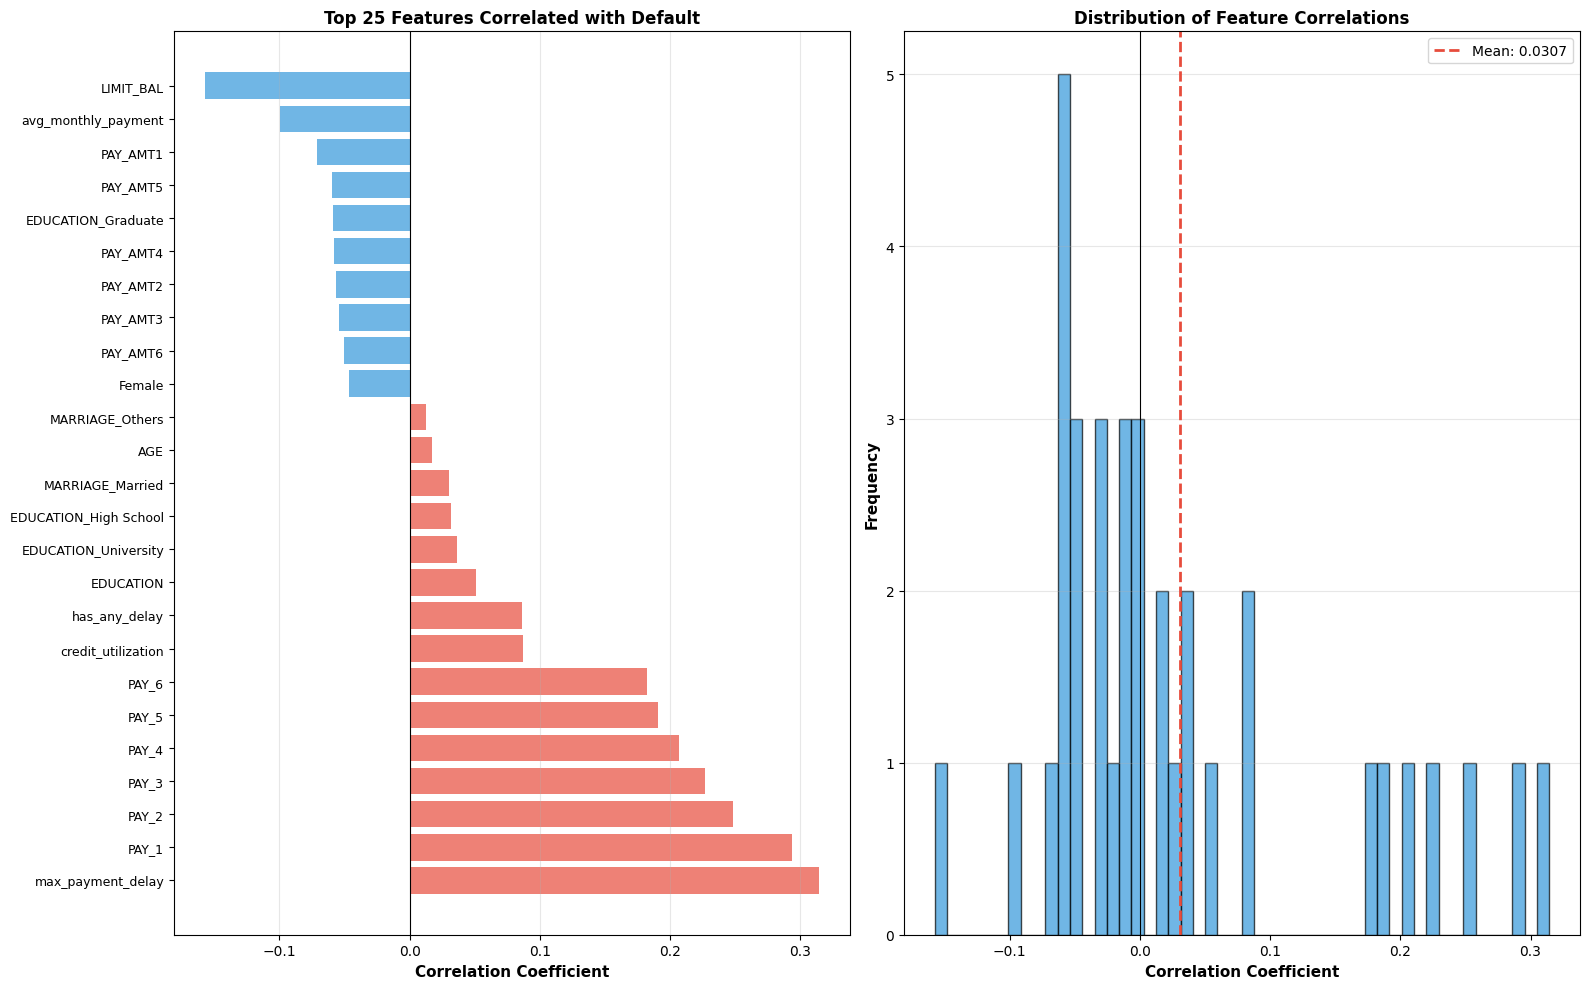


📊 CORRELATION STATISTICS:
  Mean correlation: +0.0307
  Median correlation: -0.0081
  Std dev: 0.1152
  Features with |r| > 0.15: 8
  Features with |r| > 0.10: 8
  Features with |r| > 0.05: 19


In [ ]:
# Visualize feature correlations with target
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Top positive and negative correlations
top_positive = correlations.head(15)
top_negative = correlations.tail(10)
top_combined = pd.concat([top_positive, top_negative])

# Color bars
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_combined.values]

axes[0].barh(range(len(top_combined)), top_combined.values, color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_combined)))
axes[0].set_yticklabels(top_combined.index, fontsize=9)
axes[0].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[0].set_title('Top 25 Features Correlated with Default', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# Histogram of all correlations
axes[1].hist(correlations.values, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1].axvline(x=correlations.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {correlations.mean():.4f}')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Feature Correlations', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics on correlations
print("\n📊 CORRELATION STATISTICS:")
print(f"  Mean correlation: {correlations.mean():+.4f}")
print(f"  Median correlation: {correlations.median():+.4f}")
print(f"  Std dev: {correlations.std():.4f}")
print(f"  Features with |r| > 0.15: {len(correlations[abs(correlations) > 0.15])}")
print(f"  Features with |r| > 0.10: {len(correlations[abs(correlations) > 0.10])}")
print(f"  Features with |r| > 0.05: {len(correlations[abs(correlations) > 0.05])}")